In [5]:
import os, warnings, gc, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:,.5f}')

plt.rcParams.update({
    'figure.facecolor':'#FAFAFA','axes.facecolor':'#FAFAFA',
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.labelsize':11,'xtick.labelsize':9,'ytick.labelsize':9,
})
C0, C1, C2, C3 = '#534AB7', '#D85A30', '#1D9E75', '#BA7517'

FEAT_DIR   = '/kaggle/input/datasets/jpatil98/features'    # Phase 4 output — baseline features
OUTPUT_DIR = '.models/'      # Phase 6 output
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Load baseline features (Phase 5 confirmed these beat PCA) ────────────────
print('Loading master tables (Phase 4 baseline)...')
master_train = pd.read_csv(os.path.join(FEAT_DIR, 'master_train.csv'))
master_test  = pd.read_csv(os.path.join(FEAT_DIR, 'master_test.csv'))

FEATURE_COLS = [c for c in master_train.columns if c not in ['SK_ID_CURR','TARGET']]
TARGET_COL   = 'TARGET'

X     = master_train[FEATURE_COLS].values
y     = master_train[TARGET_COL].values
X_test = master_test[FEATURE_COLS].fillna(0).values
TEST_IDS = master_test['SK_ID_CURR'].values

# Class imbalance ratio — used for scale_pos_weight
SPW = (y == 0).sum() / (y == 1).sum()

print(f'Train : {master_train.shape}')
print(f'Test  : {master_test.shape}')
print(f'Features: {len(FEATURE_COLS)}')
print(f'Default rate: {y.mean()*100:.2f}%')
print(f'scale_pos_weight: {SPW:.2f}')
print(f'\nXGBoost version : {xgb.__version__}')
print(f'LightGBM version: {lgb.__version__}')

# ── Cross-validation setup ────────────────────────────────────────────────────
N_SPLITS   = 5
RANDOM_STATE = 42
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
print(f'\n{N_SPLITS}-fold Stratified CV ready.')

Loading master tables (Phase 4 baseline)...
Train : (307511, 710)
Test  : (48744, 709)
Features: 708
Default rate: 8.07%
scale_pos_weight: 11.39

XGBoost version : 3.2.0
LightGBM version: 4.6.0

5-fold Stratified CV ready.


In [6]:
def run_xgb_cv(X, y, X_test, params, label='XGB', n_splits=5, random_state=42):
    """
    Run stratified K-fold CV with XGBoost.
    Returns:
        oof_preds    : out-of-fold predictions (for ensembling)
        test_preds   : averaged test predictions across folds
        fold_aucs    : AUC per fold
        models       : trained model per fold
    """
    skf_cv      = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof_preds   = np.zeros(len(X))
    test_preds  = np.zeros(len(X_test))
    fold_aucs   = []
    models      = []

    for fold, (tr_idx, va_idx) in enumerate(skf_cv.split(X, y)):
        X_tr, X_va = X[tr_idx], X[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]

        clf = xgb.XGBClassifier(**params)
        clf.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            verbose=False
        )

        oof_preds[va_idx] = clf.predict_proba(X_va)[:, 1]
        test_preds        += clf.predict_proba(X_test)[:, 1] / n_splits
        auc = roc_auc_score(y_va, oof_preds[va_idx])
        fold_aucs.append(auc)
        models.append(clf)
        print(f'  [{label}] Fold {fold+1}/{n_splits} — '
              f'AUC: {auc:.5f}  trees: {clf.best_iteration}')

    oof_auc  = roc_auc_score(y, oof_preds)
    mean_auc = np.mean(fold_aucs)
    std_auc  = np.std(fold_aucs)
    print(f'  [{label}] OOF AUC  : {oof_auc:.5f}')
    print(f'  [{label}] Mean AUC : {mean_auc:.5f} ± {std_auc:.5f}')
    return oof_preds, test_preds, fold_aucs, models, oof_auc


# ── Baseline parameters ───────────────────────────────────────────────────────
BASE_PARAMS = {
    'n_estimators'          : 2000,
    'learning_rate'         : 0.02,
    'max_depth'             : 6,
    'min_child_weight'      : 40,
    'subsample'             : 0.8,
    'colsample_bytree'      : 0.8,
    'reg_alpha'             : 0.1,
    'reg_lambda'            : 1.0,
    'scale_pos_weight'      : SPW,
    'eval_metric'           : 'auc',
    'early_stopping_rounds' : 100,
    'tree_method'           : 'hist',
    'random_state'          : RANDOM_STATE,
    'n_jobs'                : -1,
    'verbosity'             : 0,
}

print('Running baseline XGBoost 5-fold CV...')
print('(This takes 10-20 minutes — let it run)\n')

xgb_oof_base, xgb_test_base, xgb_aucs_base, xgb_models_base, xgb_oof_auc_base = \
    run_xgb_cv(X, y, X_test, BASE_PARAMS, label='XGB_BASE')

print(f'\nBaseline XGBoost OOF AUC: {xgb_oof_auc_base:.5f}')
gc.collect()

Running baseline XGBoost 5-fold CV...
(This takes 10-20 minutes — let it run)

  [XGB_BASE] Fold 1/5 — AUC: 0.79077  trees: 1081
  [XGB_BASE] Fold 2/5 — AUC: 0.79725  trees: 949
  [XGB_BASE] Fold 3/5 — AUC: 0.78969  trees: 1099
  [XGB_BASE] Fold 4/5 — AUC: 0.79614  trees: 1074
  [XGB_BASE] Fold 5/5 — AUC: 0.78792  trees: 1402
  [XGB_BASE] OOF AUC  : 0.79219
  [XGB_BASE] Mean AUC : 0.79236 ± 0.00368

Baseline XGBoost OOF AUC: 0.79219


832

Starting Optuna tuning — 50 trials × 3-fold CV...


  0%|          | 0/50 [00:00<?, ?it/s]


Best AUC     : 0.79279
Best params  :
  learning_rate                  : 0.016824498988586626
  max_depth                      : 5
  min_child_weight               : 83
  subsample                      : 0.7368429885440405
  colsample_bytree               : 0.6961858758480265
  colsample_bylevel              : 0.7213950548754003
  reg_alpha                      : 2.8913575164259337
  reg_lambda                     : 0.290181029487517
  gamma                          : 0.2247514204304787

Saved: best_xgb_params.json


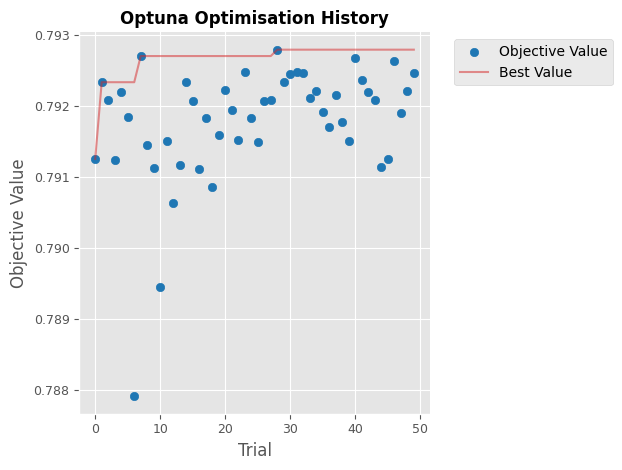

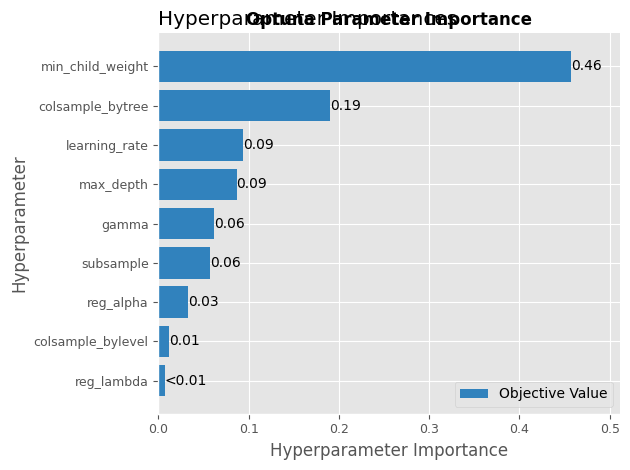

38

In [8]:
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    N_TRIALS = 50   # reduce to 20 if time-constrained

    def objective(trial):
        params = {
            'n_estimators'          : 2000,
            'learning_rate'         : trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
            'max_depth'             : trial.suggest_int('max_depth', 4, 8),
            'min_child_weight'      : trial.suggest_int('min_child_weight', 20, 100),
            'subsample'             : trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree'      : trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'colsample_bylevel'     : trial.suggest_float('colsample_bylevel', 0.5, 1.0),
            'reg_alpha'             : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            'reg_lambda'            : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            'gamma'                 : trial.suggest_float('gamma', 0.0, 1.0),
            'scale_pos_weight'      : SPW,
            'eval_metric'           : 'auc',
            'early_stopping_rounds' : 50,
            'tree_method'           : 'hist',
            'device'                : 'gpu',
            'random_state'          : RANDOM_STATE,
            'n_jobs'                : -1,
            'verbosity'             : 0,
        }

        # 3-fold CV for speed during tuning
        skf3   = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
        aucs   = []
        for tr_idx, va_idx in skf3.split(X, y):
            clf = xgb.XGBClassifier(**params)
            clf.fit(
                X[tr_idx], y[tr_idx],
                eval_set=[(X[va_idx], y[va_idx])],
                verbose=False
            )
            preds = clf.predict_proba(X[va_idx])[:, 1]
            aucs.append(roc_auc_score(y[va_idx], preds))
        return np.mean(aucs)

    study = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    print(f'Starting Optuna tuning — {N_TRIALS} trials × 3-fold CV...')
    # print('(~30-45 minutes — reduce N_TRIALS=20 if time-constrained)\n')

    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    print(f'\nBest AUC     : {study.best_value:.5f}')
    print(f'Best params  :')
    for k, v in study.best_params.items():
        print(f'  {k:<30} : {v}')

    # Build final params dict
    BEST_PARAMS = {
        'n_estimators'          : 3000,
        'scale_pos_weight'      : SPW,
        'eval_metric'           : 'auc',
        'early_stopping_rounds' : 100,
        'tree_method'           : 'hist',
        'random_state'          : RANDOM_STATE,
        'n_jobs'                : -1,
        'verbosity'             : 0,
        **study.best_params
    }

    # Save best params
    import json as _json
    save_params = {k: v for k, v in BEST_PARAMS.items()
                   if isinstance(v, (int, float, str))}
    with open(os.path.join(OUTPUT_DIR, 'best_xgb_params.json'), 'w') as f:
        _json.dump(save_params, f, indent=2)
    print(f'\nSaved: best_xgb_params.json')

    # Optuna visualisation
    try:
        import optuna.visualization.matplotlib as opt_vis
        fig = opt_vis.plot_optimization_history(study)
        plt.title('Optuna Optimisation History', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, 'optuna_history.png'), dpi=150, bbox_inches='tight')
        plt.show()

        fig2 = opt_vis.plot_param_importances(study)
        plt.title('Optuna Parameter Importance', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, 'optuna_param_importance.png'), dpi=150, bbox_inches='tight')
        plt.show()
    except Exception:
        pass

except ImportError:
    print('Optuna not installed. Run: pip install optuna')
    print('Using baseline params for final model.')
    BEST_PARAMS = BASE_PARAMS.copy()
    BEST_PARAMS['n_estimators'] = 3000

gc.collect()

In [9]:
print('Running final tuned XGBoost 5-fold CV...')
print('(10-20 minutes)\n')

xgb_oof_tuned, xgb_test_tuned, xgb_aucs_tuned, xgb_models_tuned, xgb_oof_auc_tuned = \
    run_xgb_cv(X, y, X_test, BEST_PARAMS, label='XGB_TUNED')

print(f'\nBaseline OOF AUC : {xgb_oof_auc_base:.5f}')
print(f'Tuned    OOF AUC : {xgb_oof_auc_tuned:.5f}')
print(f'Improvement      : {(xgb_oof_auc_tuned - xgb_oof_auc_base)*100:+.3f}% AUC points')

# Save tuned XGB OOF and test preds
np.save(os.path.join(OUTPUT_DIR, 'xgb_oof_tuned.npy'),  xgb_oof_tuned)
np.save(os.path.join(OUTPUT_DIR, 'xgb_test_tuned.npy'), xgb_test_tuned)

# Save all fold models
joblib.dump(xgb_models_tuned, os.path.join(OUTPUT_DIR, 'xgb_models_tuned.pkl'))
print('\nSaved: xgb_oof_tuned.npy, xgb_test_tuned.npy, xgb_models_tuned.pkl')
gc.collect()

Running final tuned XGBoost 5-fold CV...
(10-20 minutes)

  [XGB_TUNED] Fold 1/5 — AUC: 0.79241  trees: 2391
  [XGB_TUNED] Fold 2/5 — AUC: 0.80023  trees: 1753
  [XGB_TUNED] Fold 3/5 — AUC: 0.79095  trees: 2121
  [XGB_TUNED] Fold 4/5 — AUC: 0.79753  trees: 1964
  [XGB_TUNED] Fold 5/5 — AUC: 0.78937  trees: 1717
  [XGB_TUNED] OOF AUC  : 0.79405
  [XGB_TUNED] Mean AUC : 0.79410 ± 0.00411

Baseline OOF AUC : 0.79219
Tuned    OOF AUC : 0.79405
Improvement      : +0.186% AUC points

Saved: xgb_oof_tuned.npy, xgb_test_tuned.npy, xgb_models_tuned.pkl


316

In [11]:
def run_lgb_cv(X, y, X_test, params, label='LGB', n_splits=5, random_state=42):
    skf_cv     = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof_preds  = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    fold_aucs  = []
    models     = []

    for fold, (tr_idx, va_idx) in enumerate(skf_cv.split(X, y)):
        X_tr, X_va = X[tr_idx], X[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]

        dtrain = lgb.Dataset(X_tr, label=y_tr)
        dval   = lgb.Dataset(X_va, label=y_va, reference=dtrain)

        clf = lgb.train(
            params, dtrain,
            valid_sets=[dval],
            callbacks=[
                lgb.early_stopping(100, verbose=False),
                lgb.log_evaluation(period=-1)
            ]
        )

        oof_preds[va_idx] = clf.predict(X_va)
        test_preds        += clf.predict(X_test) / n_splits
        auc = roc_auc_score(y_va, oof_preds[va_idx])
        fold_aucs.append(auc)
        models.append(clf)
        print(f'  [{label}] Fold {fold+1}/{n_splits} — '
              f'AUC: {auc:.5f}  trees: {clf.best_iteration}')

    oof_auc  = roc_auc_score(y, oof_preds)
    mean_auc = np.mean(fold_aucs)
    std_auc  = np.std(fold_aucs)
    print(f'  [{label}] OOF AUC  : {oof_auc:.5f}')
    print(f'  [{label}] Mean AUC : {mean_auc:.5f} ± {std_auc:.5f}')
    return oof_preds, test_preds, fold_aucs, models, oof_auc


LGB_PARAMS = {
    'objective'         : 'binary',
    'metric'            : 'auc',
    'n_estimators'      : 3000,
    'learning_rate'     : 0.02,
    'num_leaves'        : 63,
    'max_depth'         : -1,
    'min_child_samples' : 100,
    'subsample'         : 0.8,
    'subsample_freq'    : 1,
    'colsample_bytree'  : 0.8,
    'reg_alpha'         : 0.1,
    'reg_lambda'        : 1.0,
    'scale_pos_weight'  : SPW,
    'device'            : 'gpu',
    'n_jobs'            : -1,
    'random_state'      : RANDOM_STATE,
    'verbose'           : -1,
}

print('Running LightGBM 5-fold CV...')
print('(10-15 minutes)\n')

lgb_oof, lgb_test, lgb_aucs, lgb_models, lgb_oof_auc = \
    run_lgb_cv(X, y, X_test, LGB_PARAMS, label='LGB')

np.save(os.path.join(OUTPUT_DIR, 'lgb_oof.npy'),  lgb_oof)
np.save(os.path.join(OUTPUT_DIR, 'lgb_test.npy'), lgb_test)
joblib.dump(lgb_models, os.path.join(OUTPUT_DIR, 'lgb_models.pkl'))
print('\nSaved: lgb_oof.npy, lgb_test.npy, lgb_models.pkl')
gc.collect()

Running LightGBM 5-fold CV...
(10-15 minutes)

  [LGB] Fold 1/5 — AUC: 0.79013  trees: 640
  [LGB] Fold 2/5 — AUC: 0.79853  trees: 644
  [LGB] Fold 3/5 — AUC: 0.78925  trees: 710
  [LGB] Fold 4/5 — AUC: 0.79635  trees: 881
  [LGB] Fold 5/5 — AUC: 0.78852  trees: 992
  [LGB] OOF AUC  : 0.79227
  [LGB] Mean AUC : 0.79256 ± 0.00408

Saved: lgb_oof.npy, lgb_test.npy, lgb_models.pkl


709

Finding optimal blend weight (XGB vs LGB)...
XGB OOF AUC    : 0.79405
LGB OOF AUC    : 0.79227
Best blend AUC : 0.79442  (XGB weight = 0.70)
Improvement    : +0.037% AUC points


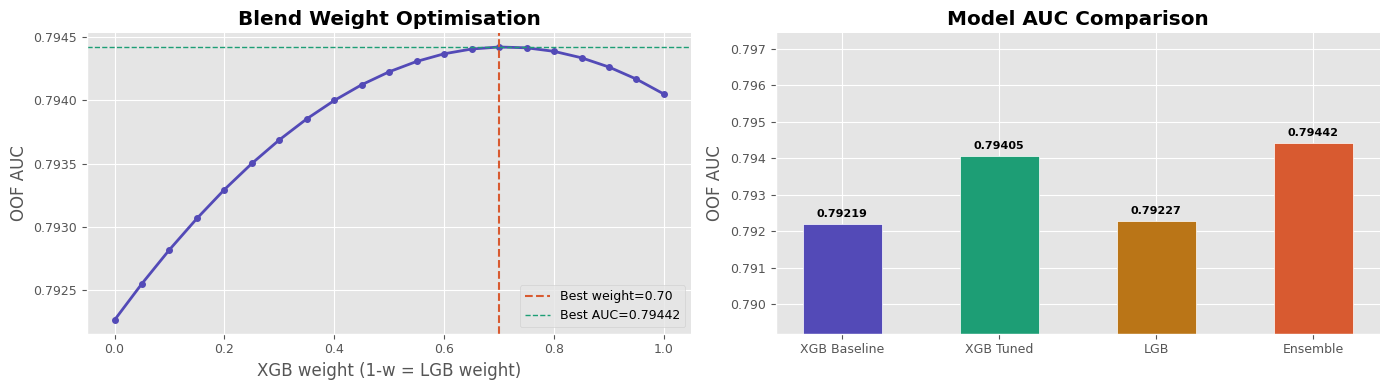

In [12]:
print('Finding optimal blend weight (XGB vs LGB)...')

weights     = np.arange(0.0, 1.01, 0.05)
blend_aucs  = []

for w in weights:
    blended = w * xgb_oof_tuned + (1 - w) * lgb_oof
    auc     = roc_auc_score(y, blended)
    blend_aucs.append(auc)

best_weight  = weights[np.argmax(blend_aucs)]
best_blend_auc = max(blend_aucs)

print(f'XGB OOF AUC    : {xgb_oof_auc_tuned:.5f}')
print(f'LGB OOF AUC    : {lgb_oof_auc:.5f}')
print(f'Best blend AUC : {best_blend_auc:.5f}  (XGB weight = {best_weight:.2f})')
print(f'Improvement    : {(best_blend_auc - xgb_oof_auc_tuned)*100:+.3f}% AUC points')

# Final blended predictions
final_oof_blend  = best_weight * xgb_oof_tuned  + (1 - best_weight) * lgb_oof
final_test_blend = best_weight * xgb_test_tuned + (1 - best_weight) * lgb_test

# Plot blend weight search
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(weights, blend_aucs, color=C0, lw=2, marker='o', markersize=4)
axes[0].axvline(best_weight, color=C1, linestyle='--', lw=1.5,
                 label=f'Best weight={best_weight:.2f}')
axes[0].axhline(best_blend_auc, color=C2, linestyle='--', lw=1,
                 label=f'Best AUC={best_blend_auc:.5f}')
axes[0].set_title('Blend Weight Optimisation', fontweight='bold')
axes[0].set_xlabel('XGB weight (1-w = LGB weight)')
axes[0].set_ylabel('OOF AUC')
axes[0].legend(fontsize=9)

# Model comparison bar
model_aucs = [
    ('XGB Baseline',  xgb_oof_auc_base),
    ('XGB Tuned',     xgb_oof_auc_tuned),
    ('LGB',           lgb_oof_auc),
    ('Ensemble',      best_blend_auc),
]
names, aucs = zip(*model_aucs)
colors_bar  = [C0, C2, C3, C1]
bars = axes[1].bar(names, aucs, color=colors_bar, edgecolor='white', width=0.5)
axes[1].set_ylim(min(aucs)-0.003, max(aucs)+0.003)
axes[1].set_title('Model AUC Comparison', fontweight='bold')
axes[1].set_ylabel('OOF AUC')
for bar, auc in zip(bars, aucs):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0002,
                  f'{auc:.5f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase6_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

Top 30 features by XGBoost importance (avg 5 folds):


,Rank,Feature,Block,Importance
0,1,APP_EXT_SOURCE_MEAN,APP,0.02708
1,2,APP_EXT_SOURCE_PRODUCT,APP,0.01986
2,3,APP_EXT_WEIGHTED,APP,0.00873
3,4,INST_24M_INST_DPD_POSITIVE_max,INST,0.00702
4,5,APP_EXT_SOURCE_MAX,APP,0.00596
5,6,NAME_EDUCATION_TYPE,NAME,0.00535
6,7,INST_24M_INST_DPD_POSITIVE_mean,INST,0.00521
7,8,CROSS_CC_UTIL_x_EXT_MEAN,CROSS,0.00463
8,9,CODE_GENDER,CODE,0.00458
9,10,CC_CNT_DRAWINGS_ATM_CURRENT_mean,CC,0.00455


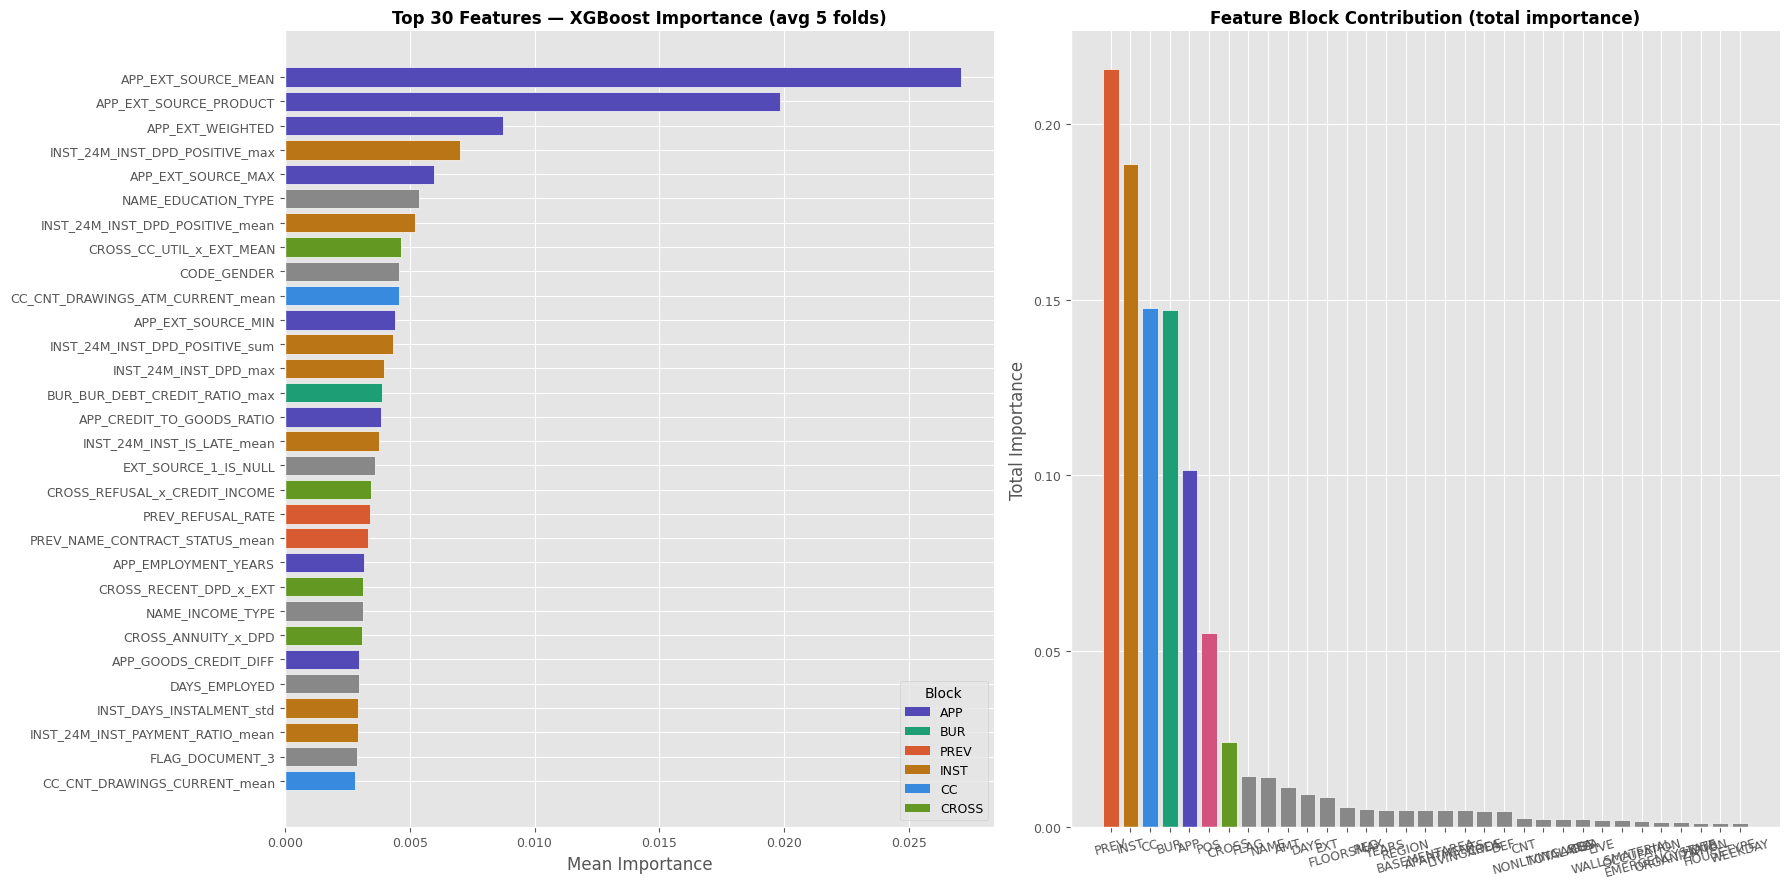

Saved: final_feature_importance.csv


In [13]:
# ── Average feature importance across all 5 folds ─────────────────────────────
imp_matrix = np.zeros(len(FEATURE_COLS))
for clf in xgb_models_tuned:
    imp_matrix += clf.feature_importances_
imp_matrix /= len(xgb_models_tuned)

imp_df = pd.DataFrame({
    'Feature'    : FEATURE_COLS,
    'Importance' : imp_matrix,
    'Block'      : [c.split('_')[0] for c in FEATURE_COLS],
}).sort_values('Importance', ascending=False).reset_index(drop=True)

imp_df['Rank'] = imp_df.index + 1

print('Top 30 features by XGBoost importance (avg 5 folds):')
display(imp_df[['Rank','Feature','Block','Importance']].head(30))

# ── Top 30 chart ──────────────────────────────────────────────────────────────
top30 = imp_df.head(30)
block_colors = {
    'APP':'#534AB7','BUR':'#1D9E75','PREV':'#D85A30',
    'INST':'#BA7517','POS':'#D4537E','CC':'#378ADD',
    'CROSS':'#639922','BBAL':'#8E44AD','OTHER':'#888888',
}
colors = [block_colors.get(b, '#888888') for b in top30['Block']]

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Feature importance
axes[0].barh(top30['Feature'], top30['Importance'], color=colors, edgecolor='white')
axes[0].set_title('Top 30 Features — XGBoost Importance (avg 5 folds)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mean Importance')
axes[0].invert_yaxis()
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=v, label=k) for k,v in block_colors.items()
                if k in top30['Block'].values]
axes[0].legend(handles=legend_elems, title='Block', fontsize=9, loc='lower right')

# Block-level total importance
block_imp = imp_df.groupby('Block')['Importance'].sum().sort_values(ascending=False)
b_colors  = [block_colors.get(b,'#888') for b in block_imp.index]
axes[1].bar(block_imp.index, block_imp.values, color=b_colors, edgecolor='white')
axes[1].set_title('Feature Block Contribution (total importance)',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total Importance')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase6_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

# Save importance
imp_df.to_csv(os.path.join(OUTPUT_DIR, 'final_feature_importance.csv'), index=False)
print('Saved: final_feature_importance.csv')

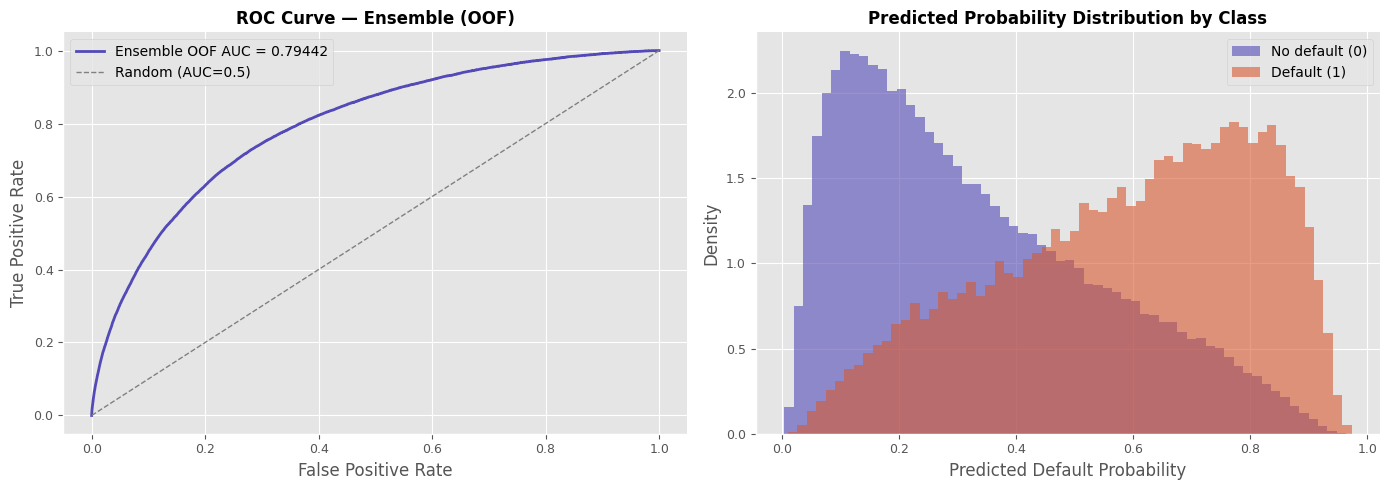

Optimal decision threshold (Youden J): 0.4476
  Sensitivity (Recall)  : 0.7280
  Specificity           : 0.7193
  False Positive Rate   : 0.2807

Business interpretation:
  Score > 0.448 → Flag as HIGH RISK (recommend review/reject)
  Score < 0.448 → Flag as LOW RISK (auto approve)


In [15]:
# ── ROC curve ─────────────────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y, final_oof_blend)
oof_auc_final = roc_auc_score(y, final_oof_blend)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
axes[0].plot(fpr, tpr, color=C0, lw=2, label=f'Ensemble OOF AUC = {oof_auc_final:.5f}')
axes[0].plot([0,1],[0,1], color='gray', linestyle='--', lw=1, label='Random (AUC=0.5)')
axes[0].set_title('ROC Curve — Ensemble (OOF)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=10)

# Score distribution by class
axes[1].hist(final_oof_blend[y==0], bins=60, color=C0, alpha=0.6,
              density=True, label='No default (0)')
axes[1].hist(final_oof_blend[y==1], bins=60, color=C1, alpha=0.6,
              density=True, label='Default (1)')
axes[1].set_title('Predicted Probability Distribution by Class',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Default Probability')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase6_roc_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Optimal threshold for business use ───────────────────────────────────────
# Youden's J statistic: maximises (sensitivity + specificity - 1)
j_scores    = tpr - fpr
best_thresh = thresholds[np.argmax(j_scores)]
best_tpr    = tpr[np.argmax(j_scores)]
best_fpr    = fpr[np.argmax(j_scores)]

print(f'Optimal decision threshold (Youden J): {best_thresh:.4f}')
print(f'  Sensitivity (Recall)  : {best_tpr:.4f}')
print(f'  Specificity           : {1-best_fpr:.4f}')
print(f'  False Positive Rate   : {best_fpr:.4f}')
print(f'\nBusiness interpretation:')
print(f'  Score > {best_thresh:.3f} → Flag as HIGH RISK (recommend review/reject)')
print(f'  Score < {best_thresh:.3f} → Flag as LOW RISK (auto approve)')

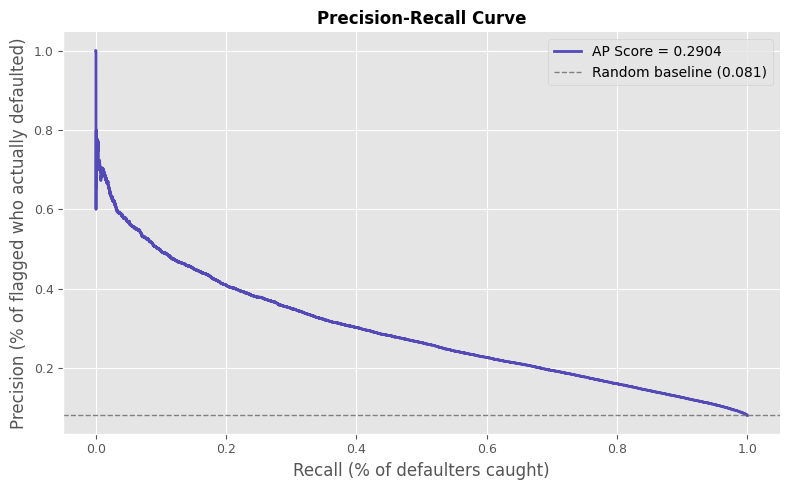

Average Precision Score: 0.29045

Business read:
  At recall=0.60 (catching 60% of defaulters):
    Precision = 0.227 (22.7% of flagged applicants actually default)


In [16]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, pr_thresholds = precision_recall_curve(y, final_oof_blend)
ap_score = average_precision_score(y, final_oof_blend)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(recall, precision, color=C0, lw=2, label=f'AP Score = {ap_score:.4f}')
ax.axhline(y.mean(), color='gray', linestyle='--', lw=1,
           label=f'Random baseline ({y.mean():.3f})')
ax.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax.set_xlabel('Recall (% of defaulters caught)')
ax.set_ylabel('Precision (% of flagged who actually defaulted)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase6_precision_recall.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Average Precision Score: {ap_score:.5f}')
print(f'\nBusiness read:')
print(f'  At recall=0.60 (catching 60% of defaulters):')
idx = np.argmin(np.abs(recall - 0.60))
print(f'    Precision = {precision[idx]:.3f} '
      f'({precision[idx]*100:.1f}% of flagged applicants actually default)')

In [17]:
# ── Generate submission ───────────────────────────────────────────────────────
submission = pd.DataFrame({
    'SK_ID_CURR' : TEST_IDS,
    'TARGET'     : final_test_blend
})

sub_path = os.path.join(OUTPUT_DIR, 'submission_ensemble.csv')
submission.to_csv(sub_path, index=False)

print(f'Submission file saved: submission_ensemble.csv')
print(f'Shape: {submission.shape}')
print(f'\nPrediction distribution:')
print(f'  Min   : {submission["TARGET"].min():.5f}')
print(f'  Max   : {submission["TARGET"].max():.5f}')
print(f'  Mean  : {submission["TARGET"].mean():.5f}')
print(f'  Median: {submission["TARGET"].median():.5f}')
display(submission.head(10))

# Also save XGB-only submission as backup
sub_xgb = pd.DataFrame({'SK_ID_CURR': TEST_IDS, 'TARGET': xgb_test_tuned})
sub_xgb.to_csv(os.path.join(OUTPUT_DIR, 'submission_xgb_only.csv'), index=False)
print('\nAlso saved: submission_xgb_only.csv (XGBoost only, as backup)')

Submission file saved: submission_ensemble.csv
Shape: (48744, 2)

Prediction distribution:
  Min   : 0.00652
  Max   : 0.94795
  Mean  : 0.32796
  Median: 0.27631


,SK_ID_CURR,TARGET
0,100001,0.29178
1,100005,0.65303
2,100013,0.20193
3,100028,0.25422
4,100038,0.62363
5,100042,0.21319
6,100057,0.07810
7,100065,0.13972
8,100066,0.10373
9,100067,0.43762



Also saved: submission_xgb_only.csv (XGBoost only, as backup)


In [18]:
print('=' * 65)
print('  PHASE 6 FINAL MODELING REPORT')
print('=' * 65)

print(f'\nMODEL PERFORMANCE (5-fold OOF AUC):')
print(f'  XGB Baseline          : {xgb_oof_auc_base:.5f}')
print(f'  XGB Tuned (Optuna)    : {xgb_oof_auc_tuned:.5f}  '
      f'({(xgb_oof_auc_tuned-xgb_oof_auc_base)*100:+.3f}pp)')
print(f'  LightGBM              : {lgb_oof_auc:.5f}')
print(f'  Ensemble (XGB+LGB)    : {best_blend_auc:.5f}  '
      f'({(best_blend_auc-xgb_oof_auc_base)*100:+.3f}pp vs baseline)')

print(f'\nENSEMBLE WEIGHTS:')
print(f'  XGBoost weight : {best_weight:.2f}')
print(f'  LightGBM weight: {1-best_weight:.2f}')

print(f'\nSUBMISSION FILES:')
print(f'  submission_ensemble.csv  — primary submission (use this)')
print(f'  submission_xgb_only.csv  — backup (XGBoost only)')

print(f'\nSAVED ARTIFACTS:')
artifacts = [
    ('xgb_models_tuned.pkl',     '5 tuned XGBoost models (one per fold)'),
    ('lgb_models.pkl',           '5 LightGBM models (one per fold)'),
    ('best_xgb_params.json',     'Best Optuna hyperparameters'),
    ('final_feature_importance.csv', 'Feature importance averaged across folds'),
    ('xgb_oof_tuned.npy',        'XGB OOF predictions'),
    ('lgb_oof.npy',              'LGB OOF predictions'),
]
for fname, desc in artifacts:
    print(f'  {fname:<40} {desc}')

print(f'\nDATA LEAKAGE CHECKLIST:')
checks = [
    'OOF predictions used for ensemble weight search — not test data',
    'Each fold model trained only on its training split',
    'Test predictions averaged across all 5 folds',
    'scale_pos_weight computed from train labels only',
    'Optuna tuning done on 3-fold CV — no test data involved',
]
for c in checks:
    print(f'  [OK] {c}')

print(f'\nPIPELINE COMPLETE')
print(f'Phase 1 → Phase 2 → Phase 2b → Phase 3 → Phase 4 → Phase 5 → Phase 6')
print(f'Submit submission_ensemble.csv to Kaggle.')

  PHASE 6 FINAL MODELING REPORT

MODEL PERFORMANCE (5-fold OOF AUC):
  XGB Baseline          : 0.79219
  XGB Tuned (Optuna)    : 0.79405  (+0.186pp)
  LightGBM              : 0.79227
  Ensemble (XGB+LGB)    : 0.79442  (+0.223pp vs baseline)

ENSEMBLE WEIGHTS:
  XGBoost weight : 0.70
  LightGBM weight: 0.30

SUBMISSION FILES:
  submission_ensemble.csv  — primary submission (use this)
  submission_xgb_only.csv  — backup (XGBoost only)

SAVED ARTIFACTS:
  xgb_models_tuned.pkl                     5 tuned XGBoost models (one per fold)
  lgb_models.pkl                           5 LightGBM models (one per fold)
  best_xgb_params.json                     Best Optuna hyperparameters
  final_feature_importance.csv             Feature importance averaged across folds
  xgb_oof_tuned.npy                        XGB OOF predictions
  lgb_oof.npy                              LGB OOF predictions

DATA LEAKAGE CHECKLIST:
  [OK] OOF predictions used for ensemble weight search — not test data
  [OK] Each